In [11]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv(r"d:\University\4th semester University\Introduction To Data Science\PROJECT\heart.csv")   # make sure file is in same folder
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
# ==============================
# 3. SPLIT FEATURES & TARGET
# ==============================
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# ==============================
# 5. DECISION TREE MODEL
# ==============================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [16]:
# ==============================
# 7. EVALUATION
# ==============================

print("\n=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 3))
print(classification_report(y_test, y_pred_dt))


=== Decision Tree ===
Accuracy: 0.754
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



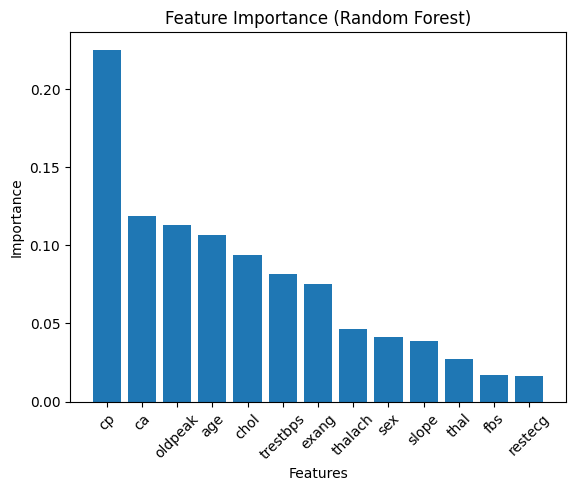


=== Feature Importance ===
     Feature  Importance
2         cp    0.225263
11        ca    0.118478
9    oldpeak    0.113268
0        age    0.106735
4       chol    0.093679
3   trestbps    0.081394
8      exang    0.075421
7    thalach    0.046207
1        sex    0.041015
10     slope    0.038537
12      thal    0.027214
5        fbs    0.016693
6    restecg    0.016097


In [17]:
# ==============================
# 8. FEATURE IMPORTANCE
# ==============================
importance = dt.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
#plot
plt.figure()
plt.bar(df_imp["Feature"], df_imp["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()
print("\n=== Feature Importance ===")
print(df_imp)

In [18]:
# ==============================
# 9. PREDICT NEW PATIENT
# ==============================
# Example patient (replace values with real ones)
new_patient = [[
    45,  # age
    1,   # sex
    2,   # cp
    130, # trestbps
    250, # chol
    0,   # fbs
    1,   # restecg
    150, # thalach
    0,   # exang
    2.3, # oldpeak
    2,   # slope
    0,   # ca
    3    # thal
]]

prediction = dt.predict(new_patient)
probability = dt.predict_proba(new_patient)

print("\n=== New Patient Prediction ===")

if prediction[0] == 1:
    print("Patient has heart disease")
else:
    print("Patient does NOT have heart disease")

print("Probability:", probability)


=== New Patient Prediction ===
Patient does NOT have heart disease
Probability: [[1. 0.]]


c:\Users\M Jazib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\M Jazib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
